In [1]:
from config_schema import HabitatConfig
from utils.habitat_worker import LoggingHabitatWorker
from dataclasses import asdict
from utils import measures

config = '/Projects/spatial_training/conf/habitat/objectnav_hm3d_ovon_rgbd_semantic.yaml'
config = '/Projects/spatial_training/conf/habitat/objectnav_hm3d_rgbd_semantic.yaml'
# config = '/Projects/spatial_training/conf/habitat/objectnav_hm3d_sparse_reward.yaml'
# config = '/Projects/configs/configs/scalevln.yaml'
# config = '/Projects/configs/configs/objectnav_hm3d_ovon.yaml'
# config = '/Projects/configs/configs/objectnav_hssd-hab_rgbd.yaml'
cfg = HabitatConfig(
    config_path = config,
    workspace= '/Projects', # folder containing "data",
    split= 'val'
)

worker = LoggingHabitatWorker(**asdict(cfg), logging_output_dir="",
    logger_actor=None)

worker.assign_shard(["mL8ThkuaVTM_23"])
# from habitat.config.default import get_config
# conf = get_config('/Projects/configs/configs/objectnav_hm3d_rgbd_semantic.yaml')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
/workspace/conda/envs/vln/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pk

skipping sim initialization since no shards provided, please call assign_shard


2026-01-30 02:27:34,967 Initializing task ObjectNav-v1


[Worker] Task Resolved: OBJECTNAV (Goal Key: objectgoal)
using seed: 79094
Actor assigned with shard of 1 episodes.


Top-down map meters per pixel: 0.005292969988659024


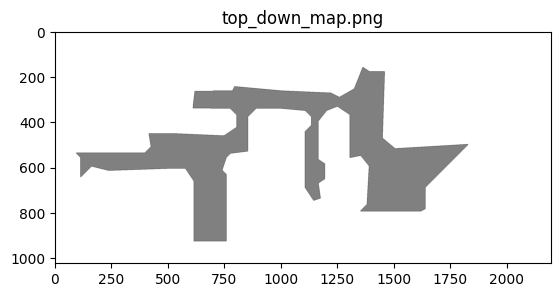

In [20]:
from habitat.utils.visualizations import maps
import numpy as np
import matplotlib.pyplot as plt
env = worker.env.habitat_env

env.reset()
# Generate topdown map
top_down_map = maps.get_topdown_map_from_sim(
    env.sim, map_resolution=1024
)
mpp = maps.calculate_meters_per_pixel(1024,env.sim)
print(f"Top-down map meters per pixel: {mpp}")
recolor_map = np.array(
    [[255, 255, 255], [128, 128, 128], [0, 0, 0]], dtype=np.uint8
)
# By default, `get_topdown_map_from_sim` returns image
# containing 0 if occupied, 1 if unoccupied, and 2 if border
# The line below recolors returned image so that
# occupied regions are colored in [255, 255, 255],
# unoccupied in [128, 128, 128] and border is [0, 0, 0]
top_down_map = recolor_map[top_down_map]
plt.imshow(top_down_map)
plt.title("top_down_map.png")
plt.show()

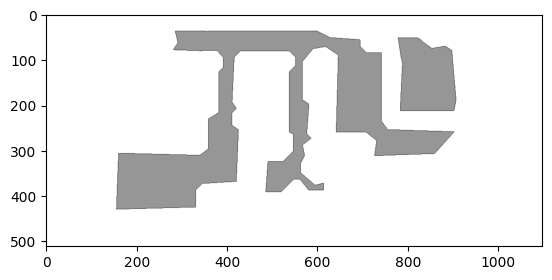

In [21]:
floor_1_map = maps.get_topdown_map(env.sim.pathfinder, env.sim.get_agent_state().position[1]-5, 512, 0.05)
mpp = maps.calculate_meters_per_pixel(1024,env.sim)
floor_1_map = maps.colorize_topdown_map(floor_1_map)
plt.imshow(floor_1_map)

In [ ]:
import json
sft_seq = "/Projects/spatial_training/dump/case_study_sft/sequence.json"
with open(sft_seq, 'r') as f:
    sft_data = json.load(f)
sft_rgb = []
env.reset()
for action in sft_data['actions']:
    obs, reward, done, info = env.step(action)
    sft_rgb.append(obs['rgb'])

In [53]:
import os
for path in worker.full_dataset.scene_ids:
    try:
        assert(os.path.exists(path))
    except:
        print(f"failed at {path}")

In [35]:
def fix_path(path):
    path_parts = path.split('/')
    fixed_parts = path_parts[:3]+['train']+path_parts[3:]
    return '/'.join(fixed_parts)

fixed_paths = [fix_path(path) for path in worker.full_dataset.scene_ids]
worker.full_dataset.check_config_paths_exist()

# print(fix_path(worker.full_dataset.scene_ids[0]))
# worker.full_dataset.scene_ids[0].split('/')[3:]

TypeError: VLNDatasetV1.check_config_paths_exist() missing 1 required positional argument: 'config'

In [32]:
len(fixed_paths)

795

In [54]:
from habitat.config.default import get_config
conf = get_config('/Projects/configs/configs/objectnav_hm3d_rgbd_semantic.yaml')

In [56]:
conf.habitat['task']

{'physics_target_sps': 60.0, 'reward_measure': 'distance_to_goal_reward', 'success_measure': 'spl', 'success_reward': 2.5, 'slack_reward': -0.01, 'end_on_success': True, 'type': 'ObjectNav-v1', 'lab_sensors': {'objectgoal_sensor': {'type': 'ObjectGoalSensor', 'goal_spec': 'TASK_CATEGORY_ID', 'goal_spec_max_val': 50}, 'compass_sensor': {'type': 'CompassSensor'}, 'gps_sensor': {'type': 'GPSSensor', 'dimensionality': 2}}, 'measurements': {'distance_to_goal': {'type': 'DistanceToGoal', 'distance_to': 'VIEW_POINTS'}, 'success': {'type': 'Success', 'success_distance': 0.1}, 'spl': {'type': 'SPL'}, 'soft_spl': {'type': 'SoftSPL'}, 'distance_to_goal_reward': {'type': 'DistanceToGoalReward'}}, 'rank0_env0_measure_names': ['habitat_perf'], 'rank0_measure_names': [], 'goal_sensor_uuid': 'objectgoal', 'count_obj_collisions': True, 'settle_steps': 5, 'constraint_violation_ends_episode': True, 'constraint_violation_drops_object': False, 'force_regenerate': False, 'should_save_to_cache': False, 'obje

#### Assign Shard to Worker
- A "shard" is a list of episode labels of the form f"{scene_id}_{episode_id}"
- Or pass None to imply the shard is the entire underlying dataset
- the worker must be assigned a shard before you can call reset.

In [8]:
worker.assign_shard(None)

2026-01-28 01:35:47,740 initializing sim Sim-v0
2026-01-28 01:35:50,508 Initializing task ObjectNav-v1


[Worker] Task Resolved: OBJECTNAV (Goal Key: objectgoal)
using seed: 3953
Actor assigned with shard of 2000 episodes.


In [3]:
worker.env.habitat_env.episodes

[VLNEpisode(episode_id=1943, scene_id='data/scene_datasets/mp3d/D7N2EKCX4Sj/D7N2EKCX4Sj.glb', scene_dataset_config='default', additional_obj_config_paths=[], start_position=[6.251160144805908, 0.1905430555343628, 3.083120107650757], start_rotation=[-0.0, 0.9659258262890683, -0.0, -0.25881904510252063], info={'geodesic_distance': 5.632524490356445}, _shortest_path_cache=None, goals=[NavigationGoal(position=[7.48360013961792, 0.007922172546386719, -2.137239933013916], radius=3.0)], start_room=None, shortest_paths=None, reference_path=[[6.251160144805908, 0.1905430555343628, 3.083120107650757], [6.046040058135986, 0.007922172546386719, 1.4801199436187744], [6.163010120391846, 0.007922172546386719, -0.3640669882297516], [7.0947699546813965, 0.007922172546386719, -2.0902299880981445], [7.48360013961792, 0.007922172546386719, -2.137239933013916]], instruction=InstructionData(instruction_text='Walk down the walkway and enter the second door on the right. Wait inside the bedroom by the chair. 

In [8]:
base_env = worker.env.habitat_env
gym_env = worker.env

base_env.task.measurements.measures.items()

odict_items([('distance_to_goal', <habitat.tasks.nav.nav.DistanceToGoal object at 0x7f49041b44c0>), ('success', <habitat.tasks.nav.nav.Success object at 0x7f49041b4640>), ('spl', <habitat.tasks.nav.nav.SPL object at 0x7f49041b4970>), ('oracle_success', <utils.measures.OracleSuccess object at 0x7f49041b4b20>), ('oracle_navigation_error', <utils.measures.OracleNavigationError object at 0x7f4a37675060>), ('oracle_spl', <utils.measures.OracleSPL object at 0x7f4a36deb250>), ('distance_to_goal_reward', <habitat.tasks.nav.nav.DistanceToGoalReward object at 0x7f49041b4d90>), ('top_down_map', <habitat.tasks.nav.nav.TopDownMap object at 0x7f49041b5000>)])

In [ ]:

_generate_auto_schema(worker,True)

{'obs': {'compass': True,
  'depth': True,
  'gps': True,
  'instruction': True,
  'rgb': True},
 'info': {'distance_to_goal': True,
  'success': True,
  'spl': True,
  'oracle_success': True,
  'oracle_navigation_error': True,
  'top_down_map': False},
 'action': True,
 'reward': True,
 'done': True,
 'timestamp': True,
 'fp_stop': True,
 'fn_stop': True,
 'stuck': True}

In [ ]:
env

In [53]:
state_dict['obs']['instruction']

{'text': 'Walk  forward through the middle archway looking down a hallway, and stop. ',
 'tokens': [2584,
  993,
  2418,
  2389,
  1506,
  147,
  1421,
  780,
  73,
  1126,
  119,
  2278,
  15],
 'trajectory_id': 654}

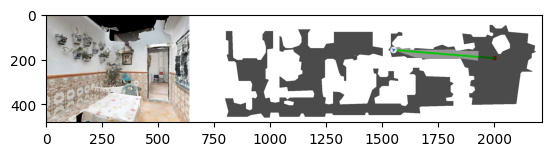

state dict structure: dict_keys(['obs', 'reward', 'done', 'info'])
{'obs': {'compass': array([-2.163899e-08], dtype=float32), 'depth': array([[[0.48338667],
        [0.48336577],
        [0.48333794],
        ...,
        [0.28929517],
        [0.28849924],
        [0.28770518]],

       [[0.4854497 ],
        [0.48542863],
        [0.48540053],
        ...,
        [0.2892877 ],
        [0.2884893 ],
        [0.2876978 ]],

       [[0.4875304 ],
        [0.4875021 ],
        [0.48748082],
        ...,
        [0.28927773],
        [0.2884794 ],
        [0.28768796]],

       ...,

       [[0.31226808],
        [0.3122652 ],
        [0.3122623 ],
        ...,
        [0.28429982],
        [0.28355503],
        [0.28281653]],

       [[0.3109399 ],
        [0.31093702],
        [0.31093416],
        ...,
        [0.28425887],
        [0.2835167 ],
        [0.2827784 ]],

       [[0.3096258 ],
        [0.30962294],
        [0.3096201 ],
        ...,
        [0.28422037],
        [0.28347

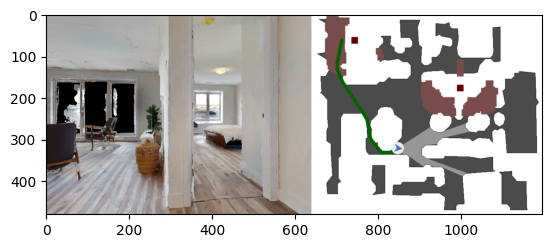

In [9]:
import matplotlib.pyplot as plt
worker.output_schema = worker._generate_auto_schema(True) # force no filtering
state_dict = worker.reset()
print(f"state dict structure: {state_dict.keys()}")
print(state_dict)
import matplotlib.pyplot as plt
from habitat.utils.visualizations import utils as vut
plt.imshow(vut.observations_to_image(worker._apply_schema(state_dict['obs'],{"rgb":True}),state_dict['info']))


In [23]:
state_dict['info']
class ObjectNavOracle:
    def __init__(self, env, success_distance,goal_radius=0.2,goal_measure="distance_to_goal"):
        from habitat.tasks.nav.shortest_path_follower import ShortestPathFollower
        """
        High-performance Oracle using MultiGoalShortestPath and episode caching.
        
        :param env: Habitat Environment. MUST NOT be RL wrapped.
        :param success_distance: Distance threshold to consider goal reached
        :param goal_radius: Radius for the low-level ShortestPathFollower
        """
        self.sim = env.sim
        self.env = env
        self.success_distance = success_distance
        self.goal_measure = goal_measure

        # We assume goal_radius for the low-level follower is similar to success_dist
        # You can tune this if the agent stops too early/late.
        self.follower = ShortestPathFollower(
            self.sim, 
            goal_radius=goal_radius, 
            return_one_hot=False
        )
        
        # Caching mechanisms
        self._cached_episode_id = None
        self._cached_candidates = None # List of Vector3 targets

    def _refresh_candidates(self, episode):
        import numpy as np
        """
        Parses episode goals once and stores all valid navigable target points.
        """
        candidates = []
        for goal in episode.goals:
            # 1. Prefer explicit ViewPoints (guaranteed navigable locations)
            if hasattr(goal, 'view_points') and goal.view_points:
                candidates.extend([self.sim.pathfinder.snap_point(vp.agent_state.position) for vp in goal.view_points])
            else:
                # 2. Fallback: Snap object position to NavMesh
                snapped_pos = self.sim.pathfinder.snap_point(goal.position)
                # Check if snap was successful (isnan check is robust for Vector3)
                if not np.isnan(snapped_pos[0]):
                    candidates.append(snapped_pos)
        
        # Fallback if metadata is totally broken (prevents crash)
        if not candidates:
            candidates = [g.position for g in episode.goals]
            
        self._cached_candidates = candidates
        self._cached_episode_id = episode.episode_id

    def get_best_action(self):
        import habitat_sim
        """
        Returns the optimal action index (int).
        Runtime: < 2ms (vs ~300ms unoptimized).
        """
        episode = self.env.current_episode
        agent_state = self.sim.get_agent_state()
        # 1. Cache Check
        if self._cached_episode_id != episode.episode_id:
            self._refresh_candidates(episode)
            
        # If no candidates exist (broken episode), Stop.
        if not self._cached_candidates:
            return 0 

        agent_pos = self.sim.pathfinder.snap_point(agent_state.position)
        
        # 2. MultiGoal Shortest Path (C++ backend)
        # Finds the closest point among all candidates in one pass.
        path = habitat_sim.MultiGoalShortestPath()
        path.requested_start = agent_pos
        path.requested_ends = self._cached_candidates
        
        found = self.sim.pathfinder.find_path(path)

        # 3. Decision Logic
        if not found:
            print("not found")
            # Agent is on an island or navmesh is broken. Return STOP (0) or Forward(1)
            return 0 
        distance_to_goal = self.env.task.measurements.measures[self.goal_measure].get_metric()
        if distance_to_goal is not None and distance_to_goal < self.success_distance:
            print("stopping")
            return 0  # STOP
        best_target = path.points[-1]
        print(best_target)
        print(agent_pos)
        return self.follower.get_next_action(best_target)

In [24]:

worker.nav_oracle = ObjectNavOracle(worker.env.habitat_env,1.0)
worker.nav_oracle.get_best_action()

Vector(0.685071, 0.00332105, -13.7198)
Vector(9.38184, 0.203321, -13.7165)


3

In [22]:
worker.nav_oracle._cached_candidates

[Vector(0.685071, 0.00332105, -13.7198)]

#### Interactive Play.
- type integers for discrete action
- type 7 to exit

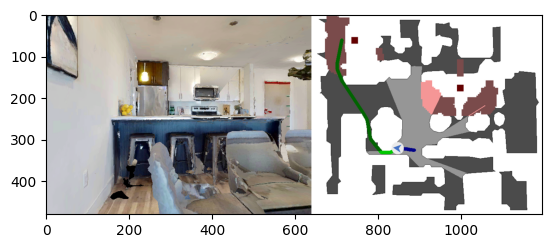

: 

In [ ]:
action = 1
from IPython.display import display, clear_output
fig, ax = plt.subplots()
while action!=0 and action!=7:
    
    # ax.imshow(state_dict['obs']['rgb'])
    
    ax.imshow(vut.observations_to_image(worker._apply_schema(state_dict['obs'],{"rgb":True}),state_dict['info']))
    fig.show()
    display(fig)
    action = input(f"instruction:\n {state_dict['obs']['instr_or_goal']}\n \nnext move?")
    clear_output()
    action = int(action)
    if action == 7:
        break
    print(f"reward: {state_dict['reward']}")
    state_dict = worker.step(action)
    

In [35]:
state_dict

{'obs': {'compass': array([-1.0471977], dtype=float32),
  'depth': array([[[0.12469812],
          [0.12482151],
          [0.12494515],
          ...,
          [0.20028631],
          [0.20028873],
          [0.20029111]],
  
         [[0.12470184],
          [0.12482522],
          [0.1249498 ],
          ...,
          [0.20113632],
          [0.20113873],
          [0.20114115]],
  
         [[0.12470647],
          [0.12482987],
          [0.12495352],
          ...,
          [0.20199116],
          [0.20199358],
          [0.201996  ]],
  
         ...,
  
         [[0.12627676],
          [0.12640235],
          [0.12652819],
          ...,
          [0.21712676],
          [0.21712394],
          [0.21712115]],
  
         [[0.12628058],
          [0.12640712],
          [0.12653296],
          ...,
          [0.2162257 ],
          [0.21622011],
          [0.21621732]],
  
         [[0.12628533],
          [0.12641093],
          [0.12653677],
          ...,
          [0.215

In [23]:
state_tuple = worker.env.step(0)

3.0

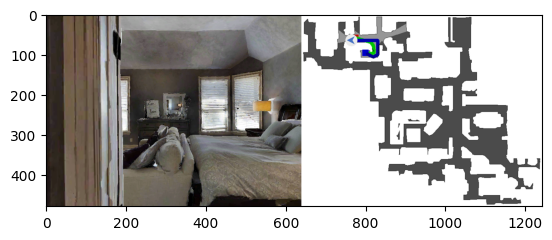

In [66]:
from habitat.utils.visualizations import utils as vut
plt.imshow(vut.observations_to_image(worker._apply_schema(state_dict['obs'],{"rgb":True}),state_dict['info']))


In [21]:
state_dict

{'obs': {'compass': array([-3.091077e-08], dtype=float32),
  'depth': array([[[0.03209643],
          [0.03226613],
          [0.03243762],
          ...,
          [0.21747856],
          [0.2174983 ],
          [0.21751805]],
  
         [[0.0320968 ],
          [0.03226649],
          [0.03243799],
          ...,
          [0.2183816 ],
          [0.21840148],
          [0.21842138]],
  
         [[0.03209717],
          [0.03226687],
          [0.03243837],
          ...,
          [0.21929213],
          [0.21931222],
          [0.2193323 ]],
  
         ...,
  
         [[0.0321292 ],
          [0.032323  ],
          [0.03251954],
          ...,
          [0.22413178],
          [0.2241288 ],
          [0.2241228 ]],
  
         [[0.03212864],
          [0.03232244],
          [0.0325186 ],
          ...,
          [0.22320445],
          [0.22320445],
          [0.22320147]],
  
         [[0.03212809],
          [0.03232189],
          [0.03251803],
          ...,
          [0.

In [47]:
state_dict['obs']

{'compass': array([-1.5543625e-08], dtype=float32),
 'depth': array([[[0.24265817],
         [0.2430413 ],
         [0.24342568],
         ...,
         [0.2582606 ],
         [0.25827652],
         [0.2582964 ]],
 
        [[0.24279158],
         [0.2431787 ],
         [0.24356349],
         ...,
         [0.2593866 ],
         [0.25940666],
         [0.2594267 ]],
 
        [[0.2429287 ],
         [0.24331269],
         [0.24370149],
         ...,
         [0.26052648],
         [0.2605467 ],
         [0.26056293]],
 
        ...,
 
        [[0.22499745],
         [0.22502461],
         [0.22505479],
         ...,
         [0.08455363],
         [0.08446424],
         [0.08437546]],
 
        [[0.22411084],
         [0.22414076],
         [0.2241677 ],
         ...,
         [0.08459712],
         [0.08450763],
         [0.08441833]],
 
        [[0.22323115],
         [0.22325492],
         [0.22326085],
         ...,
         [0.08464022],
         [0.08455107],
         [0.08446168

In [ ]:
state_dict 

In [12]:
worker.output_schema

{'obs': {'rgb': True, 'goal_name': True, 'patch_coords': False},
 'info': {'episode_label': True,
  'spl': True,
  'soft_spl': True,
  'success': True,
  'distance_to_goal': True},
 'done': True,
 'reward': True,
 'stuck': True,
 'fp_stop': True}